In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

np.random.seed(42)


In [13]:
def load_and_preprocess(filename='data.csv'):
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        return None, None, None, None

    if 'id' in df.columns:
        df = df.drop('id', axis=1)
    if 'Unnamed: 32' in df.columns:
        df = df.drop('Unnamed: 32', axis=1)

    df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

    X = df.drop('diagnosis', axis=1).values
    y = df['diagnosis'].values

    np.random.seed(42)
    indices = np.random.permutation(len(X))
    test_size = int(len(X) * 0.2)

    test_idx = indices[:test_size]
    train_idx = indices[test_size:]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)
    std[std == 0] = 1

    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std

    return X_train, X_test, y_train, y_test

In [14]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

def manhattan_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))

def minkowski_distance(x1, x2, p=3):
    return np.power(np.sum(np.power(np.abs(x1 - x2), p)), 1/p)

def cosine_distance(x1, x2):
    dot_product = np.dot(x1, x2)
    norm_x1 = np.linalg.norm(x1)
    norm_x2 = np.linalg.norm(x2)
    if norm_x1 == 0 or norm_x2 == 0: return 1.0
    return 1 - (dot_product / (norm_x1 * norm_x2))

def hamming_distance(x1, x2):
    return np.sum(x1 != x2) / len(x1)

In [15]:
class KNN:
    def __init__(self, k=3, metric='euclidean'):
        self.k = k
        self.metric = metric
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _get_distance(self, x1, x2):
        if self.metric == 'euclidean': return euclidean_distance(x1, x2)
        if self.metric == 'manhattan': return manhattan_distance(x1, x2)
        if self.metric == 'minkowski': return minkowski_distance(x1, x2)
        if self.metric == 'cosine': return cosine_distance(x1, x2)
        if self.metric == 'hamming': return hamming_distance(x1, x2)
        raise ValueError("Unknown metric")

    def predict(self, X_test):
        predictions = []
        for x in X_test:
            distances = [self._get_distance(x, x_train) for x_train in self.X_train]
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = [self.y_train[i] for i in k_indices]
            most_common = Counter(k_nearest_labels).most_common(1)
            predictions.append(most_common[0][0])

        return np.array(predictions)

In [16]:
def get_metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    return accuracy, precision, recall, [[tn, fp], [fn, tp]]

In [17]:
X_train, X_test, y_train, y_test = load_and_preprocess('data.csv')

if X_train is not None:
    k_values = [3, 4, 9, 20, 47]
    metrics_list = ['euclidean', 'manhattan', 'minkowski', 'cosine', 'hamming']

    results = {}

    print(f"{'Metric':<12} | {'K':<3} | {'Accuracy':<8}")
    print("-" * 30)

    best_acc = 0
    best_config = {}

    for metric in metrics_list:
        acc_list = []
        for k in k_values:
            model = KNN(k=k, metric=metric)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            acc, prec, rec, cm = get_metrics(y_test, preds)
            acc_list.append(acc)

            print(f"{metric:<12} | {k:<3} | {acc:.4f}")

            if acc > best_acc:
                best_acc = acc
                best_config = {
                    'k': k, 'metric': metric,
                    'prec': prec, 'rec': rec, 'cm': cm
                }
        results[metric] = acc_list

Metric       | K   | Accuracy
------------------------------
euclidean    | 3   | 0.9469
euclidean    | 4   | 0.9469
euclidean    | 9   | 0.9646
euclidean    | 20  | 0.9558
euclidean    | 47  | 0.9558
manhattan    | 3   | 0.9646
manhattan    | 4   | 0.9558
manhattan    | 9   | 0.9646
manhattan    | 20  | 0.9469
manhattan    | 47  | 0.9558
minkowski    | 3   | 0.9469
minkowski    | 4   | 0.9381
minkowski    | 9   | 0.9558
minkowski    | 20  | 0.9558
minkowski    | 47  | 0.9558
cosine       | 3   | 0.9558
cosine       | 4   | 0.9646
cosine       | 9   | 0.9646
cosine       | 20  | 0.9646
cosine       | 47  | 0.9646
hamming      | 3   | 0.7257
hamming      | 4   | 0.6283
hamming      | 9   | 0.6726
hamming      | 20  | 0.6460
hamming      | 47  | 0.6283


In [18]:
print("\n" + "="*40)
print("BEST MODEL CONFIGURATION")
print("="*40)
print(f"Best K: {best_config['k']}")
print(f"Best Distance Matrix: {best_config['metric']}")
print(f"Accuracy: {best_acc:.4f}")
print(f"Precision: {best_config['prec']:.4f}")
print(f"Recall: {best_config['rec']:.4f}")
print("Confusion Matrix:")
print(np.array(best_config['cm']))


BEST MODEL CONFIGURATION
Best K: 9
Best Distance Matrix: euclidean
Accuracy: 0.9646
Precision: 0.9524
Recall: 0.9524
Confusion Matrix:
[[69  2]
 [ 2 40]]


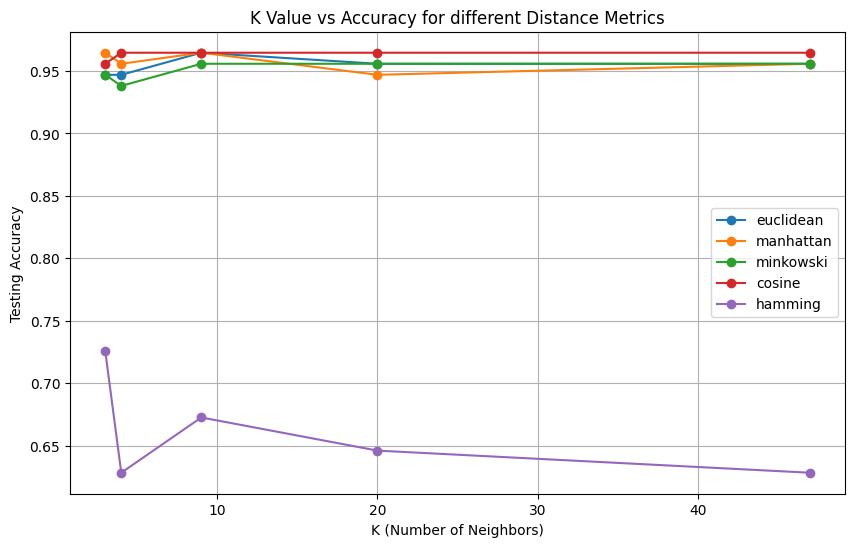

In [19]:
plt.figure(figsize=(10, 6))
for metric, accs in results.items():
    plt.plot(k_values, accs, marker='o', label=metric)

plt.title('K Value vs Accuracy for different Distance Metrics')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Testing Accuracy')
plt.legend()
plt.grid(True)
plt.show()

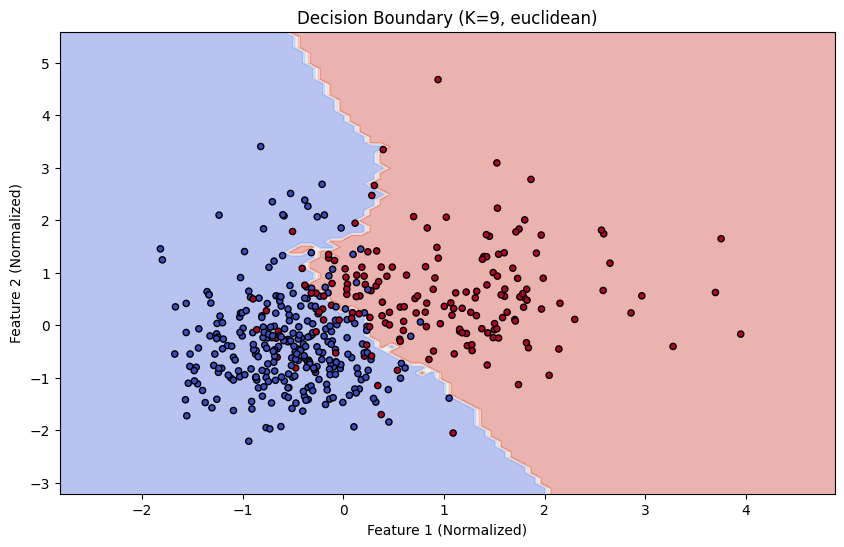

In [20]:
X_train_2d = X_train[:, :2]
X_test_2d = X_test[:, :2]

model_viz = KNN(k=best_config['k'], metric=best_config['metric'])
model_viz.fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                      np.arange(y_min, y_max, 0.1))

Z = model_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, s=20, edgecolor='k', cmap='coolwarm')
plt.title(f"Decision Boundary (K={best_config['k']}, {best_config['metric']})")
plt.xlabel("Feature 1 (Normalized)")
plt.ylabel("Feature 2 (Normalized)")
plt.show()